# Где дешевле жить? Предсказание цен в Airbnb - учимся генерировать признаки и интерпретировать результаты модели

Размер датасета: (48895, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  las

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


,missing_count,missing_pct
last_review,10052,20.56
reviews_per_month,10052,20.56
host_name,21,0.04
name,16,0.03


Количество полных дубликатов: 0
Числовых признаков: 10, категориальных/текстовых: 6
Ключевые признаки с пропусками: reviews_per_month, last_review, host_name, name


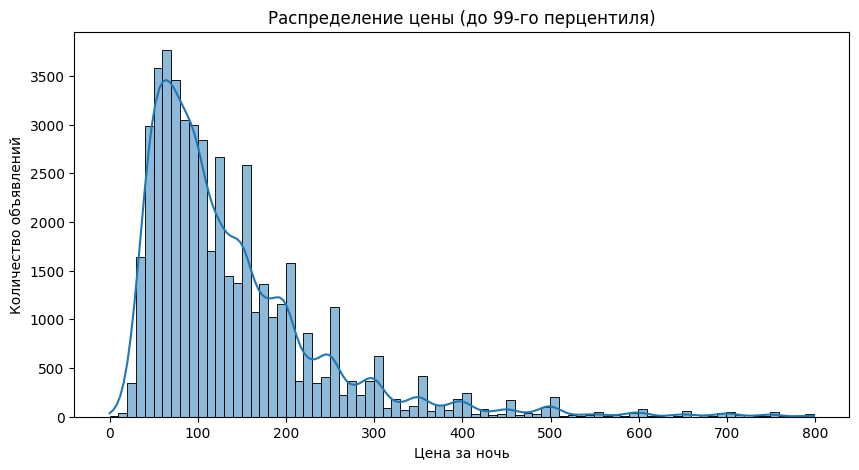

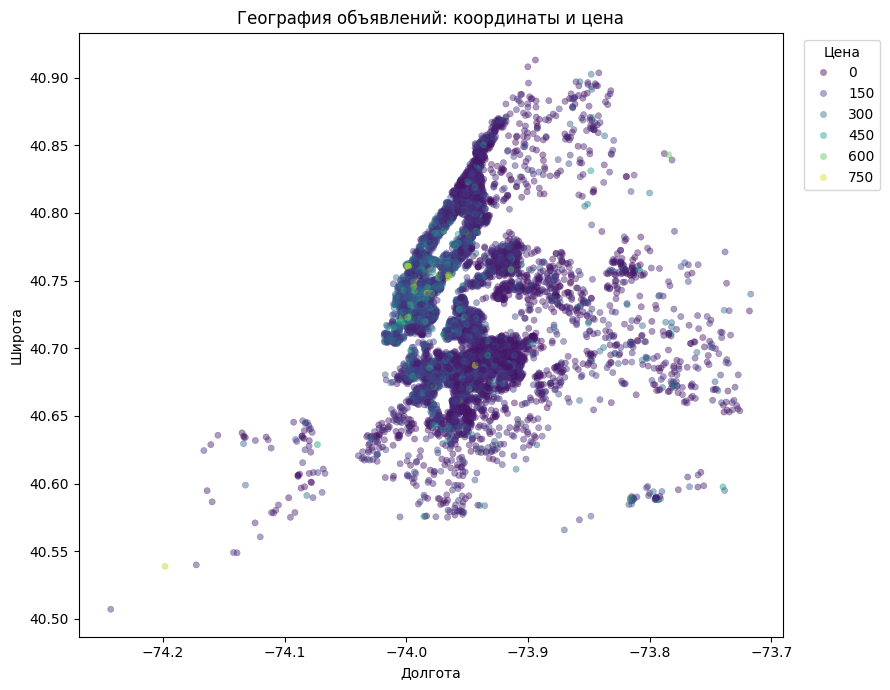

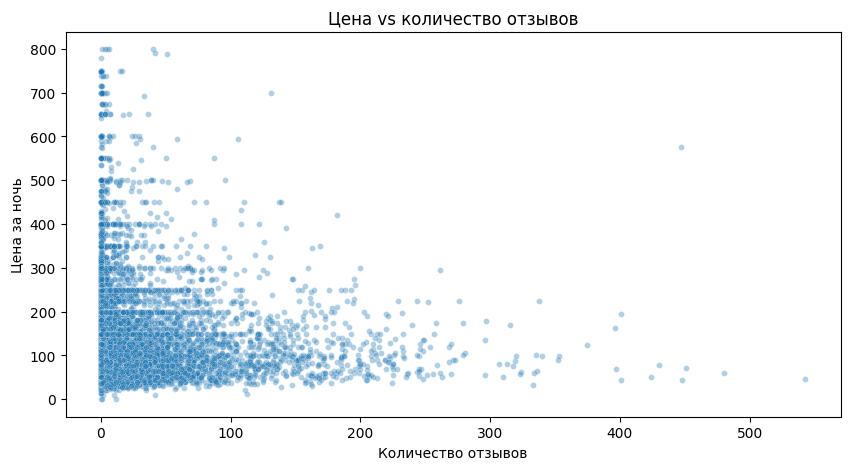

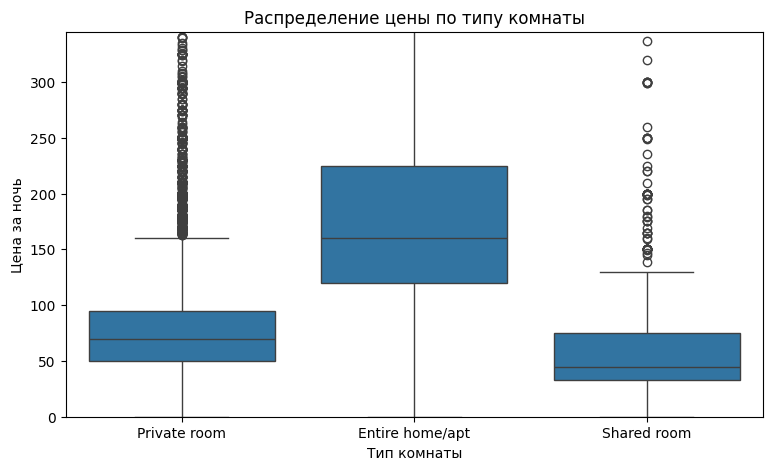

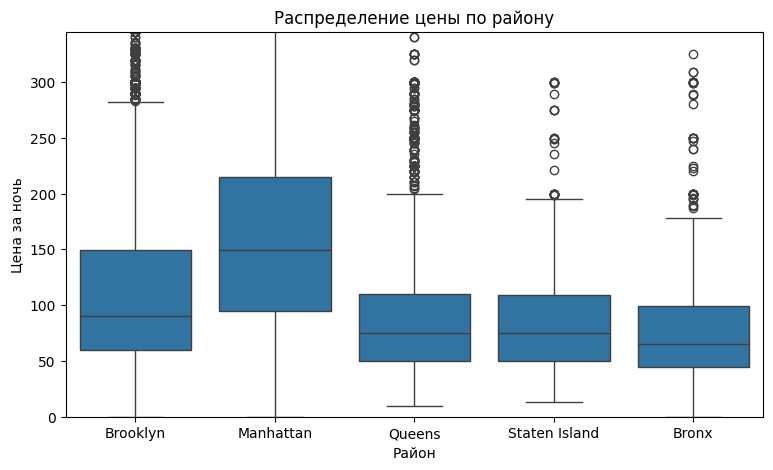


Краткие выводы EDA:
1) Цена имеет правостороннюю асимметрию: медиана=105.0, среднее=137.5.
2) По районам самая высокая медианная цена в Manhattan, самая низкая в Bronx.
3) По типам комнат медианная цена максимальна для Entire home/apt, минимальна для Shared room.
4) Большинство объявлений сконцентрировано в диапазонах координат: latitude 40.6686..40.8061, longitude -73.996..-73.9071.


In [1]:
# Импорт библиотек
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Загрузка данных
df = pd.read_csv('AB_NYC_2019.csv')
print(f'Размер датасета: {df.shape}')

# Полный обзор структуры данных
info_buffer = io.StringIO()
df.info(buf=info_buffer)
print(info_buffer.getvalue())

# Первичный просмотр
display(df.head())

# Полная проверка пропусков
missing_stats = df.isna().sum().sort_values(ascending=False)
missing_table = pd.DataFrame({
    'missing_count': missing_stats,
    'missing_pct': (missing_stats / len(df) * 100).round(2)
})
display(missing_table[missing_table['missing_count'] > 0])

# Проверка дубликатов
dup_count = df.duplicated().sum()
print(f'Количество полных дубликатов: {dup_count}')

# Короткий вывод по структуре данных
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns
print(f'Числовых признаков: {len(num_cols)}, категориальных/текстовых: {len(cat_cols)}')
print('Ключевые признаки с пропусками: reviews_per_month, last_review, host_name, name')

# Обрезаем экстремальные цены только для визуализаций, чтобы графики были читаемыми
viz_df = df[df['price'] <= df['price'].quantile(0.99)].copy()

# Гистограмма цены
plt.figure(figsize=(10, 5))
sns.histplot(viz_df['price'], bins=80, kde=True)
plt.title('Распределение цены (до 99-го перцентиля)')
plt.xlabel('Цена за ночь')
plt.ylabel('Количество объявлений')
plt.show()

# Scatterplot: география объявлений
sample_df = viz_df.sample(min(10000, len(viz_df)), random_state=42)
plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=sample_df, x='longitude', y='latitude', hue='price',
    palette='viridis', alpha=0.45, s=20, edgecolor=None
)
plt.title('География объявлений: координаты и цена')
plt.xlabel('Долгота')
plt.ylabel('Широта')
plt.legend(title='Цена', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Scatterplot: связь отзывов и цены
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=sample_df, x='number_of_reviews', y='price',
    alpha=0.35, s=18
)
plt.title('Цена vs количество отзывов')
plt.xlabel('Количество отзывов')
plt.ylabel('Цена за ночь')
plt.show()

# Boxplot: цена по типу комнаты
plt.figure(figsize=(9, 5))
sns.boxplot(data=viz_df, x='room_type', y='price')
plt.title('Распределение цены по типу комнаты')
plt.xlabel('Тип комнаты')
plt.ylabel('Цена за ночь')
plt.ylim(0, viz_df['price'].quantile(0.95))
plt.show()

# Boxplot: цена по району
plt.figure(figsize=(9, 5))
sns.boxplot(data=viz_df, x='neighbourhood_group', y='price')
plt.title('Распределение цены по району')
plt.xlabel('Район')
plt.ylabel('Цена за ночь')
plt.ylim(0, viz_df['price'].quantile(0.95))
plt.show()

# Краткие выводы по графикам
median_price = viz_df['price'].median()
mean_price = viz_df['price'].mean()
borough_median = viz_df.groupby('neighbourhood_group')['price'].median().sort_values(ascending=False)
room_median = viz_df.groupby('room_type')['price'].median().sort_values(ascending=False)
lat_range = sample_df['latitude'].quantile([0.1, 0.9]).round(4).tolist()
lon_range = sample_df['longitude'].quantile([0.1, 0.9]).round(4).tolist()

print('\nКраткие выводы EDA:')
print(f'1) Цена имеет правостороннюю асимметрию: медиана={median_price:.1f}, среднее={mean_price:.1f}.')
print(
    f'2) По районам самая высокая медианная цена в {borough_median.index[0]}, '
    f'самая низкая в {borough_median.index[-1]}.'
)
print(
    f'3) По типам комнат медианная цена максимальна для {room_median.index[0]}, '
    f'минимальна для {room_median.index[-1]}.'
)
print(
    '4) Большинство объявлений сконцентрировано в диапазонах координат: '
    f'latitude {lat_range[0]}..{lat_range[1]}, longitude {lon_range[0]}..{lon_range[1]}.'
)

In [2]:
# 2. Предобработка данных для обучения модели
df_model = df.copy()

# Удаляем признаки-идентификаторы и текстовые поля, которые не используем в базовой модели
drop_cols = ['id', 'name', 'host_id', 'host_name', 'last_review']
df_model = df_model.drop(columns=drop_cols)

# Обрабатываем пропуски
df_model['reviews_per_month'] = df_model['reviews_per_month'].fillna(0)

# Удаляем некорректные и экстремальные цены
low_q = df_model['price'].quantile(0.01)
high_q = df_model['price'].quantile(0.99)
df_model = df_model[(df_model['price'] >= low_q) & (df_model['price'] <= high_q)].copy()

# Генерируем гео-признак: дистанция до Times Square
manhattan_lat, manhattan_lon = 40.7580, -73.9855
df_model['dist_to_center'] = np.sqrt(
    (df_model['latitude'] - manhattan_lat) ** 2 + (df_model['longitude'] - manhattan_lon) ** 2
)

# Лог-трансформация целевой переменной для более стабильного обучения
df_model['price_log'] = np.log1p(df_model['price'])

# Формируем X/y
X = df_model.drop(columns=['price', 'price_log'])
y = df_model['price_log']

# Явно задаем типы признаков
cat_features = ['neighbourhood_group', 'neighbourhood', 'room_type']
num_features = [
    'latitude', 'longitude', 'minimum_nights', 'number_of_reviews',
    'reviews_per_month', 'calculated_host_listings_count',
    'availability_365', 'dist_to_center'
]

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Пайплайны предобработки
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ]
)

# Получаем итоговый список признаков после OHE на train
preprocessor.fit(X_train)
encoded_feature_names = preprocessor.get_feature_names_out()
encoded_features_df = pd.DataFrame({'feature_after_ohe': encoded_feature_names})

print(f'После предобработки размер: {df_model.shape}')
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Количество признаков после one-hot encoding: {len(encoded_feature_names)}')
display(encoded_features_df)

После предобработки размер: (48017, 13)
Train: (33611, 11), Test: (14406, 11)
Количество признаков после one-hot encoding: 232


,feature_after_ohe
0,num__latitude
1,num__longitude
2,num__minimum_nights
3,num__number_of_reviews
4,num__reviews_per_month
...,...
227,cat__neighbourhood_Woodlawn
228,cat__neighbourhood_Woodside
229,cat__room_type_Entire home/apt
230,cat__room_type_Private room


Базовый k-NN:
R2 (log): 0.5753
MAE: 46.31
RMSE: 78.19
CV R2 (mean ± std): 0.5532 ± 0.0039
Fitting 3 folds for each of 48 candidates, totalling 144 fits

Лучшая конфигурация GridSearchCV для k-NN:
{'regressor__leaf_size': 20, 'regressor__n_neighbors': 25, 'regressor__p': 1, 'regressor__weights': 'distance'}
Лучший CV R2: 0.6046

k-NN после подбора:
R2 (log): 0.6244
MAE: 43.44
RMSE: 76.01

LinearRegression: R2(log)=0.5761, MAE=46.31, RMSE=81.61

RidgeCV: R2(log)=0.5769, MAE=46.29, RMSE=81.59
  Подобранный alpha: 3.162278

LassoCV: R2(log)=0.5709, MAE=46.53, RMSE=82.07
  Подобранный alpha: 0.000254

ElasticNetCV: R2(log)=0.5709, MAE=46.53, RMSE=82.07
  Подобранный alpha: 0.000254
  Подобранный l1_ratio: 1.00

Сравнение моделей (выше R2_log и ниже MAE/RMSE - лучше):


,Model,R2_log,MAE,RMSE
0,k-NN tuned,0.624400,43.439302,76.012050
1,RidgeCV,0.576925,46.294598,81.594727
2,LinearRegression,0.576130,46.314295,81.609641
3,k-NN baseline,0.575290,46.309858,78.188077
4,LassoCV,0.570910,46.525209,82.066808
5,ElasticNetCV,0.570910,46.525209,82.066808



Лучшая линейная модель: RidgeCV
Топ-10 признаков по модулю коэффициента:


,feature,coefficient
229,cat__room_type_Entire home/apt,0.552374
27,cat__neighbourhood_Belle Harbor,0.522161
34,cat__neighbourhood_Breezy Point,0.457655
177,cat__neighbourhood_Ridgewood,-0.440197
135,cat__neighbourhood_Maspeth,-0.425084
110,cat__neighbourhood_Holliswood,0.422894
231,cat__room_type_Shared room,-0.414904
28,cat__neighbourhood_Bellerose,0.411798
200,cat__neighbourhood_Sunnyside,-0.406855
228,cat__neighbourhood_Woodside,-0.380915


Топ-5 положительных коэффициентов (рост признака повышает log-цену):


,feature,coefficient
229,cat__room_type_Entire home/apt,0.552374
27,cat__neighbourhood_Belle Harbor,0.522161
34,cat__neighbourhood_Breezy Point,0.457655
110,cat__neighbourhood_Holliswood,0.422894
28,cat__neighbourhood_Bellerose,0.411798


Топ-5 отрицательных коэффициентов (рост признака снижает log-цену):


,feature,coefficient
177,cat__neighbourhood_Ridgewood,-0.440197
135,cat__neighbourhood_Maspeth,-0.425084
231,cat__room_type_Shared room,-0.414904
200,cat__neighbourhood_Sunnyside,-0.406855
228,cat__neighbourhood_Woodside,-0.380915


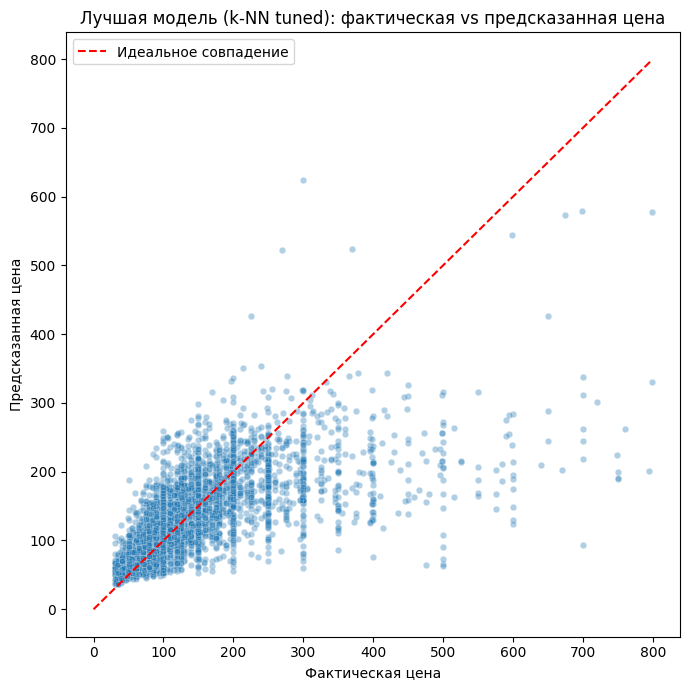

In [3]:
# 3. Обучение k-NN, линейных моделей и сравнение метрик

results_rows = []

# Базовая модель k-NN
knn_baseline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', KNeighborsRegressor())
])

knn_baseline.fit(X_train, y_train)
y_pred_log_base = knn_baseline.predict(X_test)

# Метрики считаем в исходной шкале цены
y_test_price = np.expm1(y_test)
y_pred_price_base = np.expm1(y_pred_log_base)

base_r2_log = r2_score(y_test, y_pred_log_base)
base_mae = mean_absolute_error(y_test_price, y_pred_price_base)
base_rmse = np.sqrt(mean_squared_error(y_test_price, y_pred_price_base))

print('Базовый k-NN:')
print(f'R2 (log): {base_r2_log:.4f}')
print(f'MAE: {base_mae:.2f}')
print(f'RMSE: {base_rmse:.2f}')

results_rows.append({
    'Model': 'k-NN baseline',
    'R2_log': base_r2_log,
    'MAE': base_mae,
    'RMSE': base_rmse
})

# Кросс-валидация на тренировочной части
cv = KFold(n_splits=3, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    knn_baseline, X_train, y_train, cv=cv, scoring='r2', n_jobs=-1
)
print(f'CV R2 (mean ± std): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

# Подбор гиперпараметров для k-NN
param_grid = {
    'regressor__n_neighbors': [5, 9, 15, 25],
    'regressor__weights': ['uniform', 'distance'],
    'regressor__p': [1, 2],
    'regressor__leaf_size': [20, 30, 40]
}

grid = GridSearchCV(
    estimator=Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', KNeighborsRegressor())
    ]),
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)
best_knn = grid.best_estimator_

y_pred_log_tuned = best_knn.predict(X_test)
y_pred_price_tuned = np.expm1(y_pred_log_tuned)

tuned_r2_log = r2_score(y_test, y_pred_log_tuned)
tuned_mae = mean_absolute_error(y_test_price, y_pred_price_tuned)
tuned_rmse = np.sqrt(mean_squared_error(y_test_price, y_pred_price_tuned))

print('\nЛучшая конфигурация GridSearchCV для k-NN:')
print(grid.best_params_)
print(f'Лучший CV R2: {grid.best_score_:.4f}')

print('\nk-NN после подбора:')
print(f'R2 (log): {tuned_r2_log:.4f}')
print(f'MAE: {tuned_mae:.2f}')
print(f'RMSE: {tuned_rmse:.2f}')

results_rows.append({
    'Model': 'k-NN tuned',
    'R2_log': tuned_r2_log,
    'MAE': tuned_mae,
    'RMSE': tuned_rmse
})

# Линейные модели
linear_models = {
    'LinearRegression': LinearRegression(),
    'RidgeCV': RidgeCV(alphas=np.logspace(-3, 3, 25), cv=5),
    'LassoCV': LassoCV(cv=5, random_state=42, max_iter=30000, n_jobs=-1),
    'ElasticNetCV': ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
        cv=5,
        random_state=42,
        max_iter=30000,
        n_jobs=-1
    )
}

trained_linear_models = {}

for model_name, model in linear_models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    pipe.fit(X_train, y_train)
    pred_log = pipe.predict(X_test)
    pred_price = np.expm1(pred_log)

    model_r2 = r2_score(y_test, pred_log)
    model_mae = mean_absolute_error(y_test_price, pred_price)
    model_rmse = np.sqrt(mean_squared_error(y_test_price, pred_price))

    results_rows.append({
        'Model': model_name,
        'R2_log': model_r2,
        'MAE': model_mae,
        'RMSE': model_rmse
    })

    trained_linear_models[model_name] = pipe
    print(f'\n{model_name}: R2(log)={model_r2:.4f}, MAE={model_mae:.2f}, RMSE={model_rmse:.2f}')

    reg = pipe.named_steps['regressor']
    if hasattr(reg, 'alpha_'):
        print(f'  Подобранный alpha: {reg.alpha_:.6f}')
    if hasattr(reg, 'l1_ratio_'):
        print(f'  Подобранный l1_ratio: {reg.l1_ratio_:.2f}')

results = pd.DataFrame(results_rows).sort_values('R2_log', ascending=False).reset_index(drop=True)
print('\nСравнение моделей (выше R2_log и ниже MAE/RMSE - лучше):')
display(results)

# Интерпретация коэффициентов для лучшей линейной модели
linear_results = results[results['Model'].isin(linear_models.keys())].copy()
best_linear_name = linear_results.iloc[0]['Model']
best_linear_pipeline = trained_linear_models[best_linear_name]

coef_feature_names = best_linear_pipeline.named_steps['preprocessor'].get_feature_names_out()
coef_values = best_linear_pipeline.named_steps['regressor'].coef_
coef_df = pd.DataFrame({
    'feature': coef_feature_names,
    'coefficient': coef_values,
    'abs_coefficient': np.abs(coef_values)
}).sort_values('abs_coefficient', ascending=False)

print(f'\nЛучшая линейная модель: {best_linear_name}')
print('Топ-10 признаков по модулю коэффициента:')
display(coef_df.head(10)[['feature', 'coefficient']])

print('Топ-5 положительных коэффициентов (рост признака повышает log-цену):')
display(coef_df.sort_values('coefficient', ascending=False).head(5)[['feature', 'coefficient']])

print('Топ-5 отрицательных коэффициентов (рост признака снижает log-цену):')
display(coef_df.sort_values('coefficient', ascending=True).head(5)[['feature', 'coefficient']])

# Визуальная проверка качества лучшей модели
all_models = {
    'k-NN baseline': knn_baseline,
    'k-NN tuned': best_knn,
    **trained_linear_models
}
best_model_name = results.iloc[0]['Model']
best_model = all_models[best_model_name]

best_pred_log = best_model.predict(X_test)
best_pred_price = np.expm1(best_pred_log)

plot_df = pd.DataFrame({
    'actual_price': y_test_price,
    'pred_price': best_pred_price
}).sample(min(4000, len(y_test_price)), random_state=42)

plt.figure(figsize=(7, 7))
sns.scatterplot(data=plot_df, x='actual_price', y='pred_price', alpha=0.35, s=22)
max_price = plot_df[['actual_price', 'pred_price']].max().max()
plt.plot([0, max_price], [0, max_price], color='red', linestyle='--', label='Идеальное совпадение')
plt.title(f'Лучшая модель ({best_model_name}): фактическая vs предсказанная цена')
plt.xlabel('Фактическая цена')
plt.ylabel('Предсказанная цена')
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
# 4. Финальный вывод
best_row = results.iloc[0]
best_linear_row = results[results['Model'].isin(['LinearRegression', 'RidgeCV', 'LassoCV', 'ElasticNetCV'])].iloc[0]
best_knn_row = results[results['Model'] == 'k-NN tuned'].iloc[0]

print('Финальный вывод по моделям:')
print(
    f"Лучшая модель по R2(log): {best_row['Model']} "
    f"(R2={best_row['R2_log']:.4f}, MAE={best_row['MAE']:.2f}, RMSE={best_row['RMSE']:.2f})."
)
print(
    f"Лучшая среди линейных: {best_linear_row['Model']} "
    f"(R2={best_linear_row['R2_log']:.4f}, MAE={best_linear_row['MAE']:.2f}, RMSE={best_linear_row['RMSE']:.2f})."
)
print(
    f"Сравнение с tuned k-NN: R2 difference = "
    f"{best_knn_row['R2_log'] - best_linear_row['R2_log']:+.4f}."
)

if best_knn_row['R2_log'] >= best_linear_row['R2_log']:
    print('Итог: для данной задачи нелинейная модель k-NN описывает зависимость цены лучше линейных моделей.')
else:
    print('Итог: лучшая линейная модель оказалась конкурентнее k-NN на данном наборе признаков.')

Финальный вывод по моделям:
Лучшая модель по R2(log): k-NN tuned (R2=0.6244, MAE=43.44, RMSE=76.01).
Лучшая среди линейных: RidgeCV (R2=0.5769, MAE=46.29, RMSE=81.59).
Сравнение с tuned k-NN: R2 difference = +0.0475.
Итог: для данной задачи нелинейная модель k-NN описывает зависимость цены лучше линейных моделей.
